## Question

> **How do snowfall and snowpack depth affect solar energy production?**

{insert brief discussion}
- (snowfall may block panels temporarily)
- (persistent snowpack increases albedo > increases reflected light > increases energy production?)
- (etc.)

### Imports:

In [156]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Data Cleaning:

#### Load raw data

In [153]:
# import the data
precipitation = pd.read_csv("Data/precipitation.csv")
solar = pd.read_csv("Data/solar.csv")
sun = pd.read_csv("Data/sun.csv")
weather = pd.read_csv("Data/weather.csv")

precipitation.head()

,Date,Precip in.,24-hr Snowfall in.,Snowpack Depth in.
0,1/1/2017,0.01,0.2,4
1,1/2/2017,0,0,4
2,1/3/2017,T,T,3
3,1/4/2017,0.2,0.5,3
4,1/5/2017,0.02,0.2,2.5


#### Standardize date columns

In [22]:
# making precipitation's "Date" lowercase to match all datasets
precipitation.rename(columns={"Date": "date"}, inplace=True)

# convert all date cols to datetime objects
weather['date'] = pd.to_datetime(weather['date'])
precipitation['date'] = pd.to_datetime(precipitation['date'])
sun['date'] = pd.to_datetime(sun['date'])
solar['date'] = pd.to_datetime(solar['date'])

# strip solar to date only (drop 15min time component) pre-agg 
solar['date'] = solar['date'].dt.date

#### Aggregate solar to daily totals

Precipatation, weather, and sun are all measured daily, but solar is measured every 15 minutes. To align solar's granularity with the other data, we sum all readings within each day.

In [24]:
solar_daily = (
    solar
    .groupby('date', as_index=False)['value']
    .sum()
    .rename(columns={'value': 'dailyTotal'})
)

# convert to datetime (same as date col in precipitation)
solar_daily['date'] = pd.to_datetime(solar_daily['date'])

solar_daily.head()

,date,dailyTotal
0,2017-07-27,9089.0
1,2017-07-28,29376.0
2,2017-07-29,28863.0
3,2017-07-30,30777.0
4,2017-07-31,24836.0


#### Clean precipitation cols

Raw preciptation data uses 2 dummy values, `T` (presumably for a trace amount) and `--` (for missing data). We replace `T` with 0.001 in. (near-zero numeric), and `--` with the standard `NaN` (to be dropped post-merge).

In [27]:
# cols to clean
precip_cols = ['Precip in.', '24-hr Snowfall in.', 'Snowpack Depth in.']

for col in precip_cols:
    precipitation[col] = (
        precipitation[col]
        .replace({'T': 0.001, '--': np.nan})
    )
    # convert to numeric; set values that aren't convertable to NaN
    precipitation[col] = pd.to_numeric(precipitation[col], errors='coerce')

# rename columns to be shorter
precipitation = precipitation.rename(columns={
    '24-hr Snowfall in.': 'snowfall',
    'Snowpack Depth in.': 'snowpack',
    'Precip in.': 'precip'
})

precipitation.head()

,date,precip,snowfall,snowpack
0,2017-01-01,0.010,0.200,4.0
1,2017-01-02,0.000,0.000,4.0
2,2017-01-03,0.001,0.001,3.0
3,2017-01-04,0.200,0.500,3.0
4,2017-01-05,0.020,0.200,2.5


#### Merge & filter

Merge daily solar totals with cleaned precipitation data on `date` (only keep rows where both have non-missing values for all 3 target snow/precip variables *and* solar production). Days with no solar production are dropped (likely due to sensor being offline; not actually 0-production days).  

In [29]:
snow_solar = (
    solar_daily
    # inner join on `date`
    .merge(
        precipitation[['date', 'snowfall', 'snowpack', 'precip']],
        on='date'
    )
    # drop rows w/ NaN in either snow variable or solar daily total
    .dropna(subset=['snowfall', 'snowpack', 'dailyTotal'])
)

# drop days where solar reported 0 (likely offline sensor)
snow_solar = snow_solar[snow_solar['dailyTotal'] > 0].reset_index(drop=True)


snow_solar.head()

,date,dailyTotal,snowfall,snowpack,precip
0,2017-07-27,9089.0,0.0,0.0,0.06
1,2017-07-28,29376.0,0.0,0.0,0.31
2,2017-07-29,28863.0,0.0,0.0,0.00
3,2017-07-30,30777.0,0.0,0.0,0.00
4,2017-08-04,24422.0,0.0,0.0,0.01


In [86]:
# check # days & verify # cols in merged df
print(f"Merged df has {snow_solar.shape[0]} days, {snow_solar.shape[1]} cols")

# verify no NaN
print(f"Merged df has {snow_solar.isna().sum().sum()} missing values")

Merged df has 2061 days, 6 cols
Merged df has 0 missing values


### EDA:
#### Summary statistics

In [32]:
snow_solar[['dailyTotal', 'snowfall', 'snowpack']].describe().round(2)

,dailyTotal,snowfall,snowpack
count,2061.00,2061.00,2061.00
mean,13522.33,0.25,2.22
std,10213.93,0.91,4.50
min,1.00,0.00,0.00
25%,3575.00,0.00,0.00
50%,12831.00,0.00,0.00
75%,22856.00,0.00,2.00
max,34084.00,14.30,22.00


- `dailyTotal` shows significant seasonal variation. Mean and median are relatively close, but wide and relatively balanced (i.e., between quartiles) spread indicates shift in daily production between winter/summer.
- `snowfall` is significantly right-skewed, with >75% of days having 0 snowfall; mean is pulled upward by outlier days with sizable accumulations.
- `snowpack` has wider range and higher median/quartile values than daily snowfall, reflecting persistent accumulation over time after active snowfall stops.

#### Distribution of daily solar production

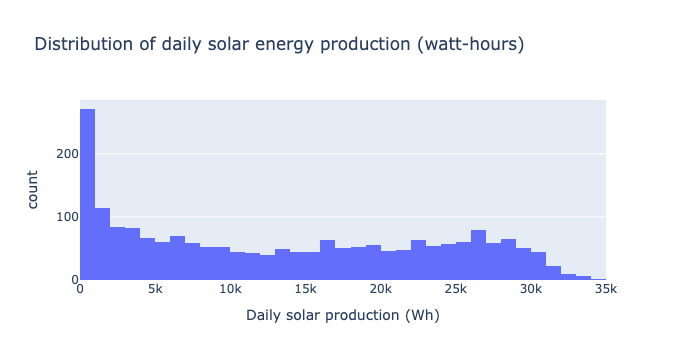

In [35]:
# start with a histogram
fig = px.histogram(
    snow_solar,
    x='dailyTotal',
    nbins=60,
    title='Distribution of daily solar energy production (watt-hours)',
    labels={'dailyTotal': 'Daily solar production (Wh)'}
)
fig.show()

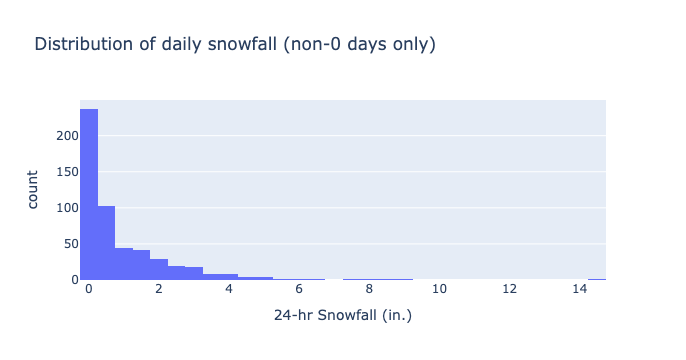

In [40]:
# distribution of snowfall (non-0 days only to evaluate shape during periods w/ active snowfall)
fig = px.histogram(
    snow_solar[snow_solar['snowfall'] > 0],
    x='snowfall',
    nbins=40,
    title='Distribution of daily snowfall (non-0 days only)',
    labels={'snowfall': '24-hr Snowfall (in.)'}
)
fig.show()

#### Snow vs. No-Snow days

A logical comparison to make is whether days with any measurable recorded snowfall produce less solar energy than days without.

In [52]:
# create indicator variable `snow_day` for whether any measurable snowfall
snow_solar['snow_day'] = (
    (snow_solar['snowfall'] > 0)
    .map({
        True: 'Snow day',
        False: ' No snow'
    })
)

# check counts
snow_solar['snow_day'].value_counts()

snow_day
 No snow    1530
Snow day     531
Name: count, dtype: int64

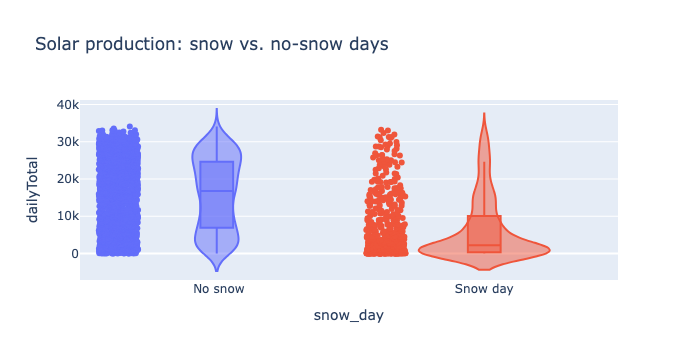

In [66]:
# make violin plot to visualize (data is high density)
fig = px.violin(
    snow_solar,
    x='snow_day',
    y='dailyTotal',
    box=True,
    points='all',
    title='Solar production: snow vs. no-snow days',
    color='snow_day'
)
# hide legend (b/c redundant)
fig.update_layout(showlegend=False)
fig.show()

In [67]:
# calculate summary stats for each group
(
    snow_solar
    .groupby('snow_day')
    .dailyTotal
    .describe()
    .round(0)
)

,count,mean,std,min,25%,50%,75%,max
snow_day,,,,,,,,
No snow,1530.0,15958.0,9640.0,2.0,6891.0,16743.0,24655.0,34084.0
Snow day,531.0,6505.0,8422.0,1.0,325.0,2217.0,10045.0,33200.0


There is a substantial difference in production between snow (median: ~2217) and non-snow days (median: ~16743). Violin plot reveals a spike in 0/near-0 solar production days for snow days, but there's more overlap at higher production values. However, the potential seasonal counfounding relationship prevent attribution to snowfall alone.

#### Scatterplots - Snowfall & Snowpack vs. Solar production

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide



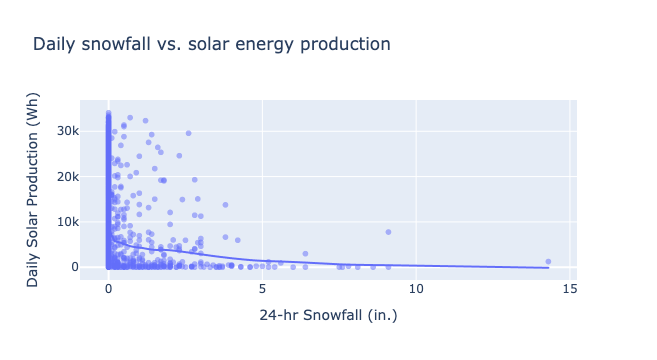

In [101]:
fig = px.scatter(
    snow_solar,
    x='snowfall',
    y='dailyTotal',
    opacity=.5,
    # use LOWESS for trendline
    trendline='lowess',
    title='Daily snowfall vs. Solar energy production',
    labels={
        'snowfall': '24-hr Snowfall (in.)',
        'dailyTotal': 'Daily Solar Production (Wh)'
    }
)
fig.show()

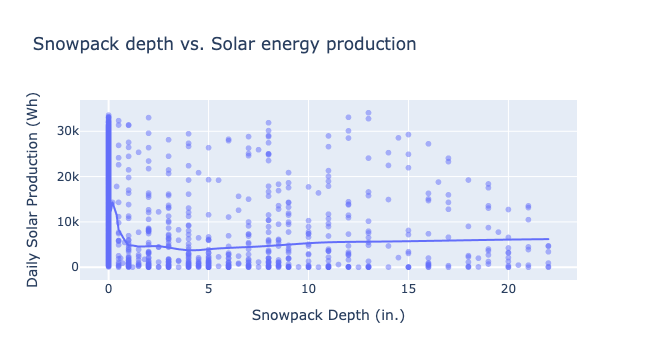

In [104]:
fig = px.scatter(
    snow_solar,
    x='snowpack',
    y='dailyTotal',
    opacity=.5,
    trendline='lowess',
    title='Snowpack depth vs. Solar energy production',
    labels={
        'snowpack': 'Snowpack Depth (in.)',
        'dailyTotal': 'Daily Solar Production (Wh)'
    }
)
fig.show()

#### Correlation matrix

Before starting to build a model, let's check correlation strength between each snow variable and solar production, as well as between snow variables (check for multicollinearity).

In [108]:
corr = (
    snow_solar[['dailyTotal', 'snowfall', 'snowpack']]
    .corr()
    .round(3)
)
print(corr)

            dailyTotal  snowfall  snowpack
dailyTotal       1.000    -0.276    -0.337
snowfall        -0.276     1.000     0.368
snowpack        -0.337     0.368     1.000


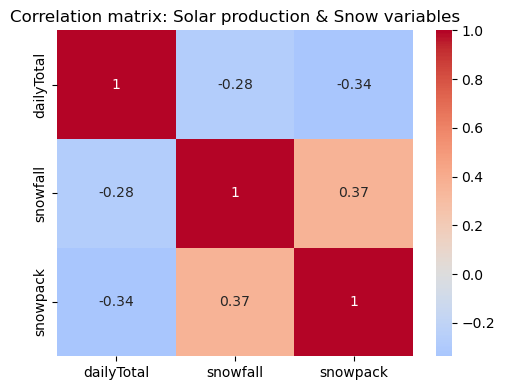

In [122]:
# make heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix: Solar production & Snow variables')
plt.tight_layout()
plt.show()

Both snow variables have moderate negative correlations with solar production. Additionally, they are moderately correlated with one another, indicating some multicollinearity (i.e., days with new snowfall tend to have more snowpack), but not strong to the extent that a regression model would be destablized. This suggests LASSO is likely to prefer one predictor over the other when penalized.

*Note: Moderate negative correlation between snowpack and solar production indicates data doesn't support hypothesis that snowpack increases production via reflected light.*

#### Seasonal context
As we expect snow *and* solar production to vary seasonally, let's visualize this relationship...

In [112]:
# create month col (date formatted as months) 
snow_solar['month'] = pd.to_datetime(snow_solar['date']).dt.month

# monthly avg solar production and average snowpack
monthly = (
    snow_solar
    .groupby('month')[['dailyTotal', 'snowpack', 'snowfall']]
    .mean()
    .reset_index()
    .round(1)
)

# dict for month names
month_names = {
    1:'Jan',
    2:'Feb',
    3:'Mar',
    4:'Apr',
    5:'May',
    6:'Jun',
    7:'Jul',
    8:'Aug',
    9:'Sep',
    10:'Oct',
    11:'Nov',
    12:'Dec'
}

# add to month df 
monthly['month_name'] = monthly['month'].map(month_names)

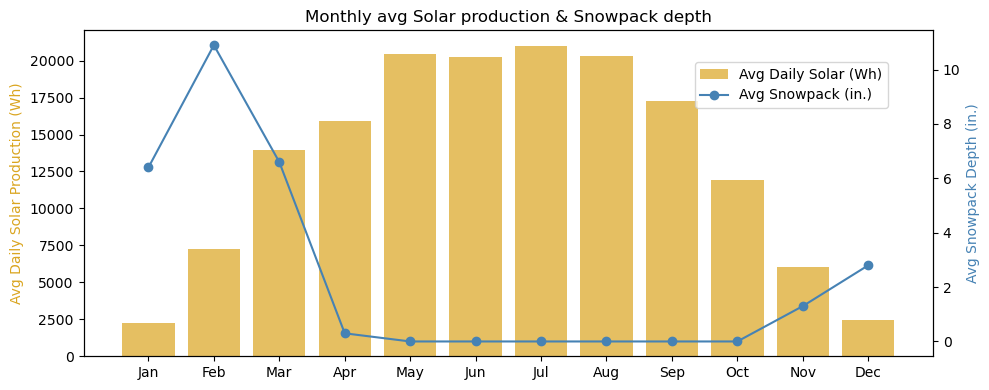

In [120]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(
    monthly['month_name'],
    monthly['dailyTotal'],
    color='goldenrod',
    alpha=.7,
    label='Avg Daily Solar (Wh)'
)

ax2.plot(
    monthly['month_name'],
    monthly['snowpack'],
    color='steelblue',
    marker='o',
    label='Avg Snowpack (in.)'
)

ax1.set_ylabel('Avg Daily Solar Production (Wh)', color='goldenrod')
ax2.set_ylabel('Avg Snowpack Depth (in.)', color='steelblue')

ax1.set_title('Monthly avg Solar production & Snowpack depth')
fig.legend(loc='upper right', bbox_to_anchor=(.9, .85))
plt.tight_layout()
plt.show()

The chart makes it clear that there's a confounding relationship here... Snowpack is high in the winter (when production is low) and pretty much zero in the summer (when production is highest).

However, this doesn't mean snowpack causes low production; day length and sun angle are likely to be the main factors. This indicates we need to use caution intrepreting regression model coefficients.

*Note: February solar production appears meaningfully higher than January's. Supports idea that day length drives solar production*

### Machine Learning

#### Method #1: MLR
Goal -> Predict daily solar energy production (continuous) using snowfall and snowpack as predictors

In [147]:
# grab features...
X = snow_solar[['snowfall', 'snowpack']]
# ...and target
y = snow_solar['dailyTotal']

# do 80/20 train/test split for both (w/ typical class seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=3870)

In [149]:
# start the 'engine'
model_lr = LinearRegression()

# fit the model
model_lr.fit(
    X=X_train,
    y=y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [150]:
# evaluate - coefficients
pd.DataFrame({
    'feature': X.columns,
    'estimate': model_lr.coef_
})

,feature,estimate
0,snowfall,-1946.044784
1,snowpack,-617.613286


In [152]:
# evaluate - R2
r2_train = model_lr.score(X_train, y_train)
r2_test = model_lr.score(X_test, y_test)

print(f"R2 (train): {r2_train}")
print(f"R2 (test): {r2_test}")

R2 (train): 0.1387133902893688
R2 (test): 0.14706871099648255


Both coefficients are negative as expected (more snowfall and deeper snowpack both predict less solar production).

The R2 (14.7%) is about what should be expected given the moderate correlations we saw earlier, and supports the idea that while the snow variables are relevant predictors, a large portion of variation in solar production is driven by other factors not included in the model.

The minimal difference between train/test R2 indicates the model generalizes well, but the low R2 values themselves suggest it's bias-heavy on the bias/variance trade-off spectrum.

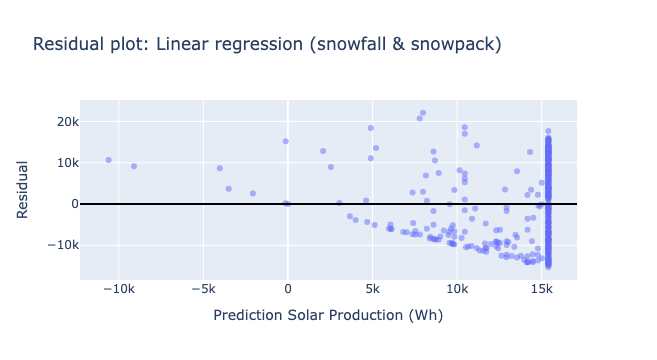

In [140]:
# residual plot to check assumptions & conditions
y_hat = model_lr.predict(X=X_test)
res = y_test.values - y_hat

fig = px.scatter(
    x=y_hat,
    y=res,
    opacity=.5,
    labels={
        'x': 'Prediction Solar Production (Wh)',
        'y': 'Residual'
    },
    title='Residual plot: Linear regression (snowfall & snowpack)'
)
fig.add_hline(y=0, line_color='black')
fig.show()

 The clear hetereoskedasticity in the residual plot makes sense given the high density of low production on snowdays and the wide spread on non-snow days earlier observed. As snow variables are the only predictors, the model predicts ~15k Wh for any non-snow day (resulting in the dense stack of points at ~15k Wh), while actual production varies widly from factors not included in the model.

 The hetereoskedasticity (errors growing larger at higher predicted production values) supports the notion that while snow variables *do* negatively impact solar production, they're insufficient alone to explain the variance on days with high-production. Adding additional atmosphereic predictors and utilizing LASSO regularization will be necesary to address the unmodeled variance. 